# Data Challenge : Lynred data

---

In [ ]:
import pandas as pd
import numpy as np
import cv2
import glob
import os
import matplotlib.pyplot as plt
from skimage import io
import json
from pathlib import Path

---

## Loading the data

In [ ]:
def load_image(image_path):
    """
    Loads an image from a given file path.

    Args:
        image_path (str): The complete path to the image file.

    Returns:
        numpy.ndarray: The loaded image as an array of pixels.
    """
    image = io.imread(image_path)
    return image

def load_json(file_path):
    """
    Loads a JSON file and returns its content.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        list/dict: The parsed JSON data.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    return data

def get_defect_coordinates(json_data, image_number):
    """
    Parses JSON data to extract defect coordinates for a specific image number.

    Args:
        json_data (list): The list of dictionaries loaded from the JSON file.
        image_number (str or int): The specific image number to look for in the JSON.

    Returns:
        dict: A dictionary where keys are x-coordinates (columns) and values 
              are dictionaries containing lists of 'start' and 'stop' y-coordinates.
    """
    defect_dict = {}
    
    for item in json_data:
        value = item.get('signal', {}).get(str(image_number))
        
        if value is not None:
            for x_coord in item.get('x_coord', []):
                
                defect_dict[x_coord] = {
                    'start': item.get('y_start', []), 
                    'stop': item.get('y_stop', []),
                    'type': item.get('name', [])
                }

    return defect_dict

def normalize_to_8bit(image_array):
    """
    Normalizes an image array (e.g., 16-bit) to an 8-bit range (0 to 255).

    Args:
        image_array (numpy.ndarray): The input image array.

    Returns:
        numpy.ndarray: The normalized image array with dtype uint8.
    """
    img_np = np.array(image_array, dtype=np.float32)
    
    val_min = np.min(img_np)
    val_max = np.max(img_np)
    
    if val_max == val_min:
        return np.zeros_like(img_np, dtype=np.uint8)
        
    normalized_image = ((img_np - val_min) / (val_max - val_min)) * 255
    
    return normalized_image.astype(np.uint8)

def replace_defects(img, defects):
    """
    Replaces defective pixels in an image with 0 (black) based on provided coordinates.

    Args:
        img (numpy.ndarray): The original image array.
        defects (dict): A dictionary of defect coordinates generated by `get_defect_coordinates`.

    Returns:
        numpy.ndarray: A copy of the image with the defective pixels set to 0.
    """
    image_copy = img.copy()
    
    for x_coord, values in defects.items():
        for start_y, end_y in zip(values['start'], values['stop']):
            image_copy[start_y:end_y + 1, x_coord] = 0
            
    return image_copy

def analyser_et_corriger_image(image_path, json_path=None, show_images=True):
    """
    Fonction globale qui charge les documents, extrait les défauts, 
    corrige l'image et affiche les résultats.
    
    Args:
        image_path (str): Le chemin vers l'image.
        json_path (str, optional): Le chemin vers le fichier JSON. S'il n'est pas fourni, 
                                   il sera déduit à partir du chemin de l'image.
        show_images (bool): True pour afficher l'image originale et l'image corrigée.
        image_number (str/int): Le numéro de l'image à analyser dans le JSON (par défaut "0").
        
    Returns:
        dict: Un dictionnaire avec les x en index, associés à une liste de tuples (Ystart, Ystop).
    """

    nom_fichier = os.path.basename(image_path)
    chaine_numero = nom_fichier.split('_')[1].split('.')[0]
    image_number = int(chaine_numero)
    
    if json_path is None:
        dossier_image = os.path.dirname(image_path)
        fichiers_json = glob.glob(os.path.join(dossier_image, "*.json"))
        json_path = fichiers_json[0]

    raw_image = load_image(image_path)
    defect_data = load_json(json_path)
    
    raw_defects = get_defect_coordinates(defect_data, image_number)
            
    normalized_img = normalize_to_8bit(raw_image)
    corrected_image = replace_defects(normalized_img, raw_defects)
    
    if show_images:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        axes[0].imshow(normalized_img, cmap='gray')
        axes[0].set_title("Image Originale (Normalisée)")
        axes[0].axis('off')
        
        axes[1].imshow(corrected_image, cmap='gray')
        axes[1].set_title("Image avec les erreurs superposées")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    return raw_defects

In [3]:
deflect = analyser_et_corriger_image(
    image_path=r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn with columns 1\frame_0497.png",
    show_images=True
)
print(deflect)


KeyboardInterrupt



# Evaluat the data

In [ ]:
def evaluate_single_image(eval_image_path, detected_dict=None):
    nom_fichier = os.path.basename(eval_image_path)
    image_number = int(nom_fichier.split('_')[1].split('.')[0])
    
    result_dir = os.path.dirname(eval_image_path)
    sim_dir = os.path.dirname(result_dir)
    seq_dir = os.path.dirname(sim_dir)
    
    gt_image_path = os.path.join(seq_dir, "low dyn", nom_fichier)
    
    fichiers_json = glob.glob(os.path.join(sim_dir, "*.json"))
    if not fichiers_json:
        raise FileNotFoundError(f"Aucun fichier JSON trouvé dans le dossier : {sim_dir}")
    json_path = fichiers_json[0]
    
    with open(json_path, "r", encoding="utf-8") as file:
        json_data = json.load(file)
        
    true_def_dict = {}
    types_presents = set()
    
    for item in json_data:
        value = item.get('signal', {}).get(str(image_number))
        if value is not None:
            def_type = item.get('name', 'unknown')
            if isinstance(def_type, list) and len(def_type) > 0:
                def_type = def_type[0]
            types_presents.add(def_type)
            
            for x_coord in item.get('x_coord', []):
                true_def_dict[x_coord] = {
                    'start': item.get('y_start', []), 
                    'stop': item.get('y_stop', []),
                    'type': def_type
                }
                
    gt = io.imread(gt_image_path).astype(np.float32, copy=False)
    res = io.imread(eval_image_path).astype(np.float32, copy=False)
    
    true_mask_global = np.zeros(gt.shape, dtype=bool)
    masks_by_type = {t: np.zeros(gt.shape, dtype=bool) for t in types_presents}
    
    for col_str, info in true_def_dict.items():
        col_idx = int(col_str)
        def_type = info.get('type', 'unknown')
        for start, stop in zip(info.get('start', []), info.get('stop', [])):
            true_mask_global[start:stop, col_idx] = True
            masks_by_type[def_type][start:stop, col_idx] = True
            
    if detected_dict is None:
        detected_mask = (res != gt)
    else:
        detected_mask = np.zeros(gt.shape, dtype=bool)
        for col_str, info in detected_dict.items():
            col_idx = int(col_str)
            for start, stop in zip(info.get('start', []), info.get('stop', [])):
                detected_mask[start:stop, col_idx] = True
                
    residu_sq = (res - gt) ** 2
    
    tp_global = np.logical_and(detected_mask, true_mask_global).sum()
    fp_global = np.logical_and(detected_mask, ~true_mask_global).sum()
    fn_global = np.logical_and(~detected_mask, true_mask_global).sum()
    
    prec_global = tp_global / (tp_global + fp_global) if (tp_global + fp_global) > 0 else 0.0
    rec_global  = tp_global / (tp_global + fn_global) if (tp_global + fn_global) > 0 else 0.0
    f1_global   = 2 * prec_global * rec_global / (prec_global + rec_global) if (prec_global + rec_global) > 0 else 0.0
    
    sq_def_global = residu_sq[true_mask_global].sum()
    cnt_def_global = true_mask_global.sum()
    sq_ok_global = residu_sq[~true_mask_global].sum()
    cnt_ok_global = (~true_mask_global).sum()
    
    rmse_def_global = np.sqrt(sq_def_global / cnt_def_global) if cnt_def_global > 0 else 0.0
    rmse_ok_global  = np.sqrt(sq_ok_global / cnt_ok_global) if cnt_ok_global > 0 else 0.0
    
    rmse_def_norm = max(0.0, 1.0 - (rmse_def_global / 40.0))
    rmse_ok_norm  = max(0.0, 1.0 - (rmse_ok_global / 40.0))
    overall = (0.34 * f1_global + 0.33 * rmse_def_norm + 0.33 * rmse_ok_norm)
    
    results = {
        "Global": {
            "TP": int(tp_global), "FP": int(fp_global), "FN": int(fn_global),
            "Precision": prec_global, "Recall": rec_global, "F1_Score": f1_global,
            "RMSE_def": rmse_def_global, "RMSE_ok": rmse_ok_global,
            "Overall_Score": overall
        },
        "By_Type": {}
    }
    
    for def_type, type_mask in masks_by_type.items():
        tp_t = np.logical_and(detected_mask, type_mask).sum()
        fn_t = np.logical_and(~detected_mask, type_mask).sum()
        rec_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
        
        sq_def_t = residu_sq[type_mask].sum()
        cnt_def_t = type_mask.sum()
        rmse_def_t = np.sqrt(sq_def_t / cnt_def_t) if cnt_def_t > 0 else 0.0
        
        results["By_Type"][def_type] = {
            "TP": int(tp_t),
            "FN": int(fn_t),
            "Recall": rec_t,
            "RMSE_def": rmse_def_t
        }
        
    print("=== RÉSULTATS GLOBAUX ===")
    print(f"TP: {results['Global']['TP']} | FP: {results['Global']['FP']} | FN: {results['Global']['FN']}")
    print(f"Precision: {results['Global']['Precision']:.4f} | Recall: {results['Global']['Recall']:.4f} | F1: {results['Global']['F1_Score']:.4f}")
    print(f"RMSE_def: {results['Global']['RMSE_def']:.2f} | RMSE_ok: {results['Global']['RMSE_ok']:.2f}")
    print(f"Score Final (Overall): {results['Global']['Overall_Score']:.4f}")
    print("\n=== RÉSULTATS PAR TYPE DE DÉFAUT ===")
    for def_type, metrics in results["By_Type"].items():
        print(f"[{def_type.upper()}]")
        print(f"  TP: {metrics['TP']} | FN: {metrics['FN']}")
        print(f"  Recall (Rappel): {metrics['Recall']:.4f} | RMSE_def: {metrics['RMSE_def']:.2f}")
    print("====================================")
    
    return results

# Correction algorythme

## Moyenne des pixels voisins kernel

In [1]:
dico_formes = {
    # ==========================================
    # 1. LES CROIX
    # ==========================================
    "cross_3x3": [
        [0, 1, 0],
        [1, 1, 1],
        [0, 1, 0]
    ],
    "cross_5x5": [
        [0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0],
        [1, 1, 1, 1, 1],
        [0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0]
    ],
    "cross_7x7": [
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0]
    ],

    # ==========================================
    # 2. LES CARRÉS
    # ==========================================
    "square_3x3": [
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ],
    "square_5x5": [
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]
    ],
    "square_7x7": [
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1]
    ],

    # ==========================================
    # 3. LES RONDS
    # ==========================================
    "circle_5x5": [
        [0, 1, 1, 1, 0],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [0, 1, 1, 1, 0]
    ],
    "circle_7x7": [
        [0, 0, 1, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [0, 1, 1, 1, 1, 1, 0],
        [0, 0, 1, 1, 1, 0, 0]
    ],

    # ==========================================
    # 4. LES PAPILLONS
    # ==========================================
    "butterfly_3x3": [
        [1, 0, 1],
        [1, 0, 1],
        [1, 0, 1]
    ],
    "butterfly_5x5": [
        [0, 1, 0, 1, 0],
        [1, 1, 0, 1, 1],
        [1, 1, 0, 1, 1],
        [1, 1, 0, 1, 1],
        [0, 1, 0, 1, 0]
    ],
    "butterfly_7x7": [
        [0, 0, 1, 0, 1, 0, 0],
        [0, 1, 1, 0, 1, 1, 0],
        [1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 0, 1, 1, 1],
        [0, 1, 1, 0, 1, 1, 0],
        [0, 0, 1, 0, 1, 0, 0]
    ]
}

In [ ]:
dico_poids = {
    # ==========================================
    # 1. UNIFORME
    # ==========================================
    "uniform_3x3": [
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ],
    "uniform_5x5": [
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]
    ],
    "uniform_7x7": [
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1]
    ],

    # ==========================================
    # 2. GAUSSIEN
    # ==========================================
    "gaussian_3x3": [
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ],
    "gaussian_5x5": [
        [1,  4,  6,  4, 1],
        [4, 16, 24, 16, 4],
        [6, 24, 36, 24, 6],
        [4, 16, 24, 16, 4],
        [1,  4,  6,  4, 1]
    ],
    "gaussian_7x7": [
        [ 1,  2,   4,   8,   4,  2,  1],
        [ 2,  4,   8,  16,   8,  4,  2],
        [ 4,  8,  16,  32,  16,  8,  4],
        [ 8, 16,  32,  64,  32, 16,  8],
        [ 4,  8,  16,  32,  16,  8,  4],
        [ 2,  4,   8,  16,   8,  4,  2],
        [ 1,  2,   4,   8,   4,  2,  1]
    ],

    # ==========================================
    # 3. PYRAMIDE
    # ==========================================
    "pyramid_3x3": [
        [1, 1, 1],
        [1, 2, 1],
        [1, 1, 1]
    ],
    "pyramid_5x5": [
        [1, 1, 1, 1, 1],
        [1, 2, 2, 2, 1],
        [1, 2, 3, 2, 1],
        [1, 2, 2, 2, 1],
        [1, 1, 1, 1, 1]
    ],
    "pyramid_7x7": [
        [1, 1, 1, 1, 1, 1, 1],
        [1, 2, 2, 2, 2, 2, 1],
        [1, 2, 3, 3, 3, 2, 1],
        [1, 2, 3, 4, 3, 2, 1],
        [1, 2, 3, 3, 3, 2, 1],
        [1, 2, 2, 2, 2, 2, 1],
        [1, 1, 1, 1, 1, 1, 1]
    ],

    # ==========================================
    # 4. NOEUD PAPILLONS
    # ==========================================
    "bowtie_3x3": [
        [1, 0, 1],
        [2, 0, 2],
        [1, 0, 1]
    ],
    "bowtie_5x5": [
        [1, 1, 0, 1, 1],
        [1, 2, 0, 2, 1],
        [1, 2, 0, 2, 1],
        [1, 2, 0, 2, 1],
        [1, 1, 0, 1, 1]
    ],
    "bowtie_7x7": [
        [1, 1, 1, 0, 1, 1, 1],
        [1, 2, 2, 0, 2, 2, 1],
        [1, 2, 3, 0, 3, 2, 1],
        [1, 2, 3, 0, 3, 2, 1],
        [1, 2, 3, 0, 3, 2, 1],
        [1, 2, 2, 0, 2, 2, 1],
        [1, 1, 1, 0, 1, 1, 1]
    ]
}

In [ ]:
def smooth_defect_advanced(shape_matrix, weight_matrix, img, defect_dico, method="mean"):
    """
    Applique une correction sur les défauts en utilisant une forme, des poids, et une méthode mathématique.
    """
    result_image = np.copy(img).astype(float)
    height, width = img.shape
    
    # Combinaison formes et poids
    combined_matrix = np.array(shape_matrix) * np.array(weight_matrix)
    kh, kw = combined_matrix.shape
    center_y, center_x = kh // 2, kw // 2
    
    for x_str, info in defect_dico.items():
        x = int(x_str) 
        if not (0 <= x < width): continue
            
        # Extraction des listes start et stop
        starts = info.get('start', [])
        stops = info.get('stop', [])
        
        # Parcours couplé avec zip()
        for y_start, y_end in zip(starts, stops):
            y_start = max(0, y_start)
            y_end = min(height - 1, y_end)
            
            for y in range(y_start, y_end + 1):
                voisins = []
                poids = []
                
                for i in range(kh):
                    for j in range(kw):
                        w = combined_matrix[i, j]
                        if w > 0:
                            ny, nx = y + (i - center_y), x + (j - center_x)
                            if 0 <= ny < height and 0 <= nx < width:
                                voisins.append(img[ny, nx])
                                poids.append(w)
                
                if not voisins:
                    continue
                    
                if method == "mean":
                    result_image[y, x] = np.average(voisins, weights=poids)
                
                elif method == "median":
                    result_image[y, x] = np.median(voisins)
                    
                elif method == "trimmed_mean":
                    p10 = np.percentile(voisins, 10)
                    p90 = np.percentile(voisins, 90)
                    voisins_filtres = [v for v in voisins if p10 <= v <= p90]
                    
                    result_image[y, x] = np.mean(voisins_filtres) if voisins_filtres else np.median(voisins)

    return result_image.astype(img.dtype)

In [ ]:
# Chemins
base_dir = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_3\low dyn with columns 3"
result_dir = os.path.join(base_dir, "result")
os.makedirs(result_dir, exist_ok=True)

img_path = os.path.join(base_dir, "frame_0497.png")
img_originale = io.imread(img_path)

# Méthodes à tester
methodes_agregation = ["mean", "median", "trimmed_mean"]
scores_globaux = []

# LA BOUCLE DE TEST AUTOMATISÉE
for nom_forme, matrice_forme in dico_formes.items():
    taille = nom_forme.split('_')[1]
    
    for nom_poids, matrice_poids in dico_poids.items():
        if taille not in nom_poids: 
            continue 
        
        for methode in methodes_agregation:
            print(f"\n---> TEST : {nom_forme} | {nom_poids} | {methode}")
            
            img_lissee = smooth_defect_advanced(
                shape_matrix=matrice_forme, 
                weight_matrix=matrice_poids, 
                img=img_originale, 
                defect_dico=deflect, 
                method=methode
            )
            
            # Sauvegarde TEMPORAIRE
            chemin_temporaire = os.path.join(result_dir, "frame_0497.png")
            io.imsave(chemin_temporaire, img_lissee, check_contrast=False)
            
            # Évaluation
            scores = evaluate_single_image(chemin_temporaire)
            
            # Renommage du fichier pour archivage
            nom_final = f"frame_0497_{nom_forme}_{nom_poids}_{methode}.png"
            chemin_final = os.path.join(result_dir, nom_final)
            
            # Suppression préalable si le fichier final existe déjà
            if os.path.exists(chemin_final):
                os.remove(chemin_final)
            os.rename(chemin_temporaire, chemin_final)
            
            # Stockage du score
            scores_globaux.append({
                "config": f"{nom_forme} + {nom_poids} + {methode}",
                "score": scores['Global']['Overall_Score']
            })

# BILAN DES PERFORMANCES
print("\n" + "="*40)
print("TOP 3 DES MEILLEURES CONFIGURATIONS")
print("="*40)
scores_globaux.sort(key=lambda x: x["score"], reverse=True)

for i in range(min(3, len(scores_globaux))):
    print(f"{i+1}. {scores_globaux[i]['config']}")
    print(f"   Score Overall : {scores_globaux[i]['score']:.4f}\n")"

SyntaxError: unterminated string literal (detected at line 1) (1025526702.py, line 1)

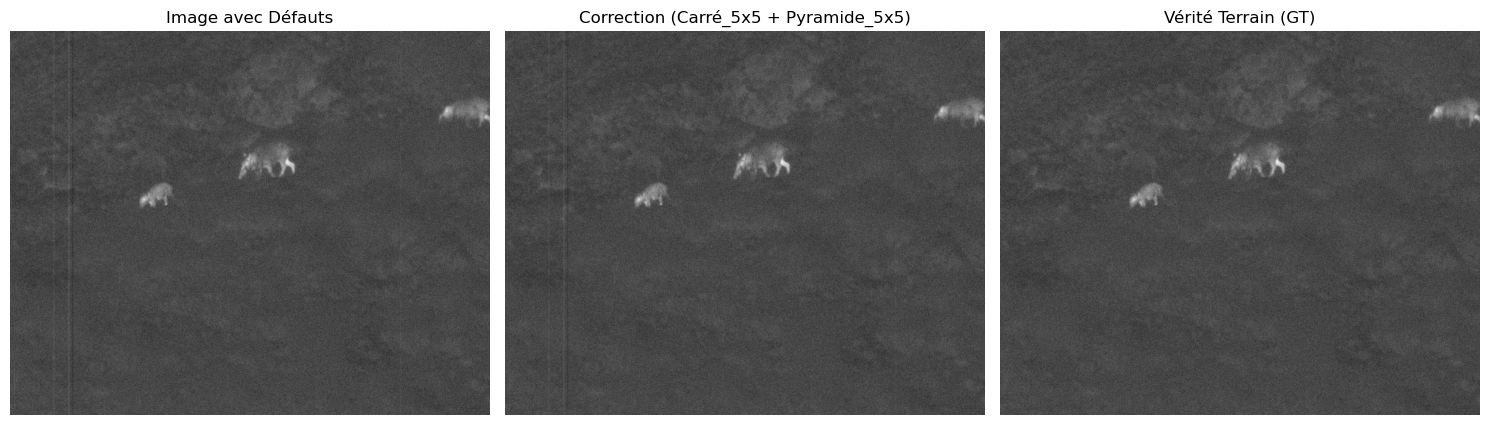

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Définition des matrices
carre_5x5 = np.ones((5, 5))
pyramide_5x5 = np.array([
    [1, 1, 1, 1, 1],
    [1, 2, 2, 2, 1],
    [1, 2, 4, 2, 1],
    [1, 2, 2, 2, 1],
    [1, 1, 1, 1, 1]
])

# Chemins
img_path_def = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn with columns 1\frame_0497.png"
img_path_gt = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn\frame_0497.png"
json_path = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn with columns 1\SXGA_sequence_1_config_1.json"

img_def = load_image(img_path_def)
img_gt = load_image(img_path_gt)
json_data = load_json(json_path)
defects = get_defect_coordinates(json_data, 0) # Le nombre corespond au chiffre de l'image

# Calcul de la correction
img_corrigee = smooth_defect_advanced(
    shape_matrix=carre_5x5,
    weight_matrix=pyramide_5x5,
    img=img_def.astype(float),
    defect_dico=defects,
    method="mean"
)

# Affichage
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Image avec Défauts")
plt.imshow(normalize_to_8bit(img_def), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Correction (Carré_5x5 + Pyramide_5x5)")
plt.imshow(normalize_to_8bit(img_corrigee), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Vérité Terrain (GT)")
plt.imshow(normalize_to_8bit(img_gt), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Une mesure de similarité entre deux imagess

print(img_def.mean())
print(img_corrigee.mean())
print(img_gt.mean())

21054.621235656738
21054.596155067382
21054.52436065674


## Copier de la left columns

In [ ]:
def copy_right_pixel_propagated(img, defect_dico):
    """
    Copie la colonne de droite, en utilisant l'image en cours de modification 
    pour permettre la propagation des corrections.
    """
    result_image = np.copy(img).astype(float)
    height, width = img.shape
    
    sorted_x = sorted([int(x) for x in defect_dico.keys()], reverse=True)
    
    for x in sorted_x:
        if not (0 <= x < width - 1): 
            continue
            
        info = defect_dico.get(str(x)) or defect_dico.get(x)
        starts = info.get('start', [])
        stops = info.get('stop', [])
        
        for y_start, y_end in zip(starts, stops):
            y_start = max(0, y_start)
            y_end = min(height - 1, y_end)
            
            result_image[y_start:y_end + 1, x] = result_image[y_start:y_end + 1, x + 1]

    return result_image.astype(img.dtype)

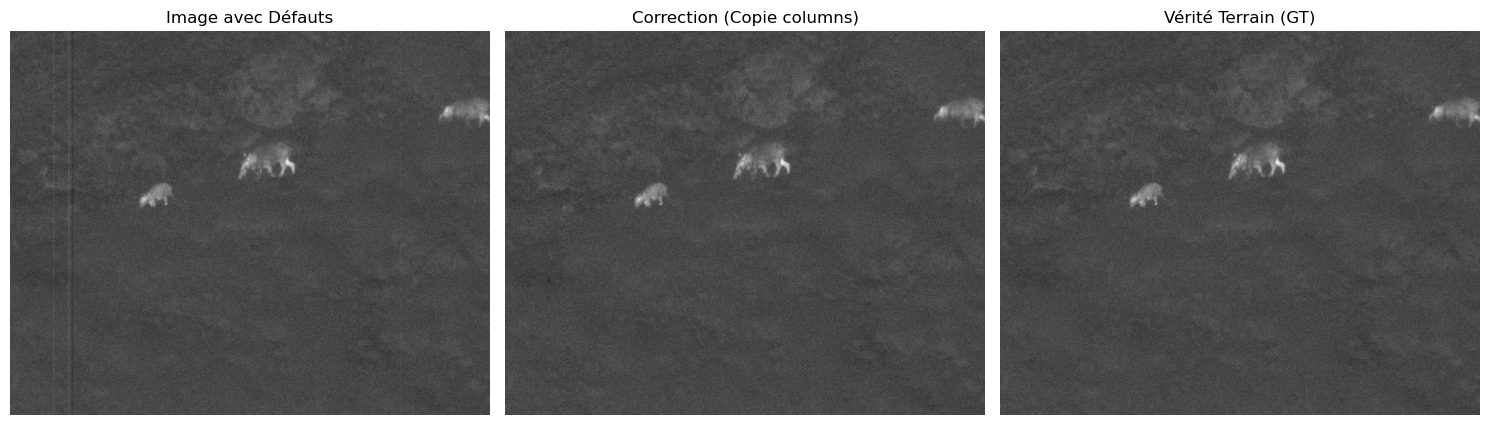

{115: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 116: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 117: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 118: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 155: {'start': [0], 'stop': [1024], 'type': 'noisy_blinking'}, 156: {'start': [0], 'stop': [1024], 'type': 'noisy_blinking'}, 157: {'start': [0], 'stop': [1024], 'type': 'noisy_blinking'}, 158: {'start': [0], 'stop': [1024], 'type': 'noisy_blinking'}, 165: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 166: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 167: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 168: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 1040: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 1041: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 1042: {'start': [0], 'stop': [1024], 'type': 'noisy'}, 1043: {'start': [0], 'stop': [1024], 'type': 'noisy'}}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Chemins
img_path_def = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn with columns 1\frame_0497.png"
img_path_gt = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn\frame_0497.png"
json_path = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn with columns 1\SXGA_sequence_1_config_1.json"

img_def = load_image(img_path_def)
img_gt = load_image(img_path_gt)
json_data = load_json(json_path)
defects = get_defect_coordinates(json_data, 497) # Le nombre corespond au chiffre de l'image

img_corrigee = copy_right_pixel_propagated(img_def.astype(float), defects)

# Affichage
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Image avec Défauts")
plt.imshow(normalize_to_8bit(img_def), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Correction (Copie columns)")
plt.imshow(normalize_to_8bit(img_corrigee), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Vérité Terrain (GT)")
plt.imshow(normalize_to_8bit(img_gt), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(defects) # POur regarder a peut près où son les defects

In [ ]:
# Une mesure de similarité entre deux imagess

print(img_def.mean())
print(img_corrigee.mean())
print(img_gt.mean())

np.linalg.norm(img_corrigee - img_gt, 'fro')**2/img_gt.size

21054.621235656738
21054.526208496092
21054.52436065674


np.float64(18.98646697998047)

In [ ]:
import os
from skimage import io

# Chemins
base_dir = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn with columns 1"
result_dir = os.path.join(base_dir, "result")
os.makedirs(result_dir, exist_ok=True)

img_path = os.path.join(base_dir, "frame_0000.png")
chemin_temporaire = os.path.join(result_dir, "frame_0000.png")
img_originale = io.imread(img_path)

# Application fonction
print("---> TEST : copy_right_pixel_propagated")
img_lissee = copy_right_pixel_propagated(img_originale, deflect)

# Sauvegarde
io.imsave(chemin_temporaire, img_lissee, check_contrast=False)

# Évaluation
scores = evaluate_single_image(chemin_temporaire)

# Affichage du résultat spécifique
print("\n" + "="*40)
print("Résultat de la fonction Copi-Paste")
print("="*40)
print(f"Score Overall : {scores['Global']['Overall_Score']:.4f}")

---> TEST : copy_right_pixel_propagated
=== RÉSULTATS GLOBAUX ===
TP: 32635 | FP: 0 | FN: 133
Precision: 1.0000 | Recall: 0.9959 | F1: 0.9980
RMSE_def: 43.60 | RMSE_ok: 0.00
Score Final (Overall): 0.6693

=== RÉSULTATS PAR TYPE DE DÉFAUT ===
[BLINKING]
  TP: 12288 | FN: 0
  Recall (Rappel): 1.0000 | RMSE_def: 45.80
[NOISY]
  TP: 12190 | FN: 98
  Recall (Rappel): 0.9920 | RMSE_def: 40.13
[NOISY_BLINKING]
  TP: 8157 | FN: 35
  Recall (Rappel): 0.9957 | RMSE_def: 45.17

🏆 RÉSULTAT DE LA PROPAGATION 🏆
Score Overall : 0.6693


## La méthode avec OpenCV

In [ ]:
import cv2
import numpy as np

def inpaint_opencv_correction(img, defect_dico, inpaint_radius=3):
    """
    Crée un masque à partir du dictionnaire de défauts, puis applique
    l'algorithme d'inpainting de Navier-Stokes via OpenCV.
    """
    # Création masque vide
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    height, width = img.shape[:2]
    
    # Remplissage masque avec le dictionnaire
    for x_str, info in defect_dico.items():
        x = int(x_str) 
        if not (0 <= x < width): 
            continue
            
        starts = info.get('start', [])
        stops = info.get('stop', [])
        
        for y_start, y_end in zip(starts, stops):
            y_start = max(0, y_start)
            y_end = min(height - 1, y_end)
            
            # On marque les pixels défectueux en blanc sur le masque
            mask[y_start:y_end + 1, x] = 255
            
    # Application inpainting OpenCV
    result_image = cv2.inpaint(img, mask, inpaintRadius=inpaint_radius, flags=cv2.INPAINT_NS)
    
    return result_image

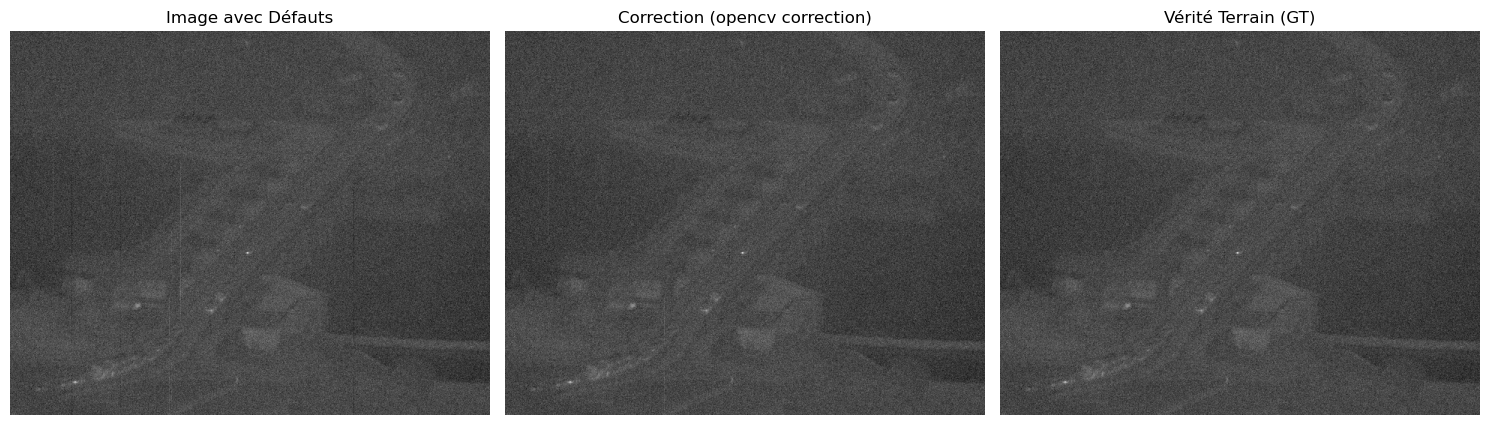

{82: {'start': [192, 329, 456], 'stop': [295, 416, 512], 'type': 'blinking'}, 147: {'start': [203, 364, 457], 'stop': [324, 428, 509], 'type': 'noisy'}, 215: {'start': [266, 442], 'stop': [326, 501], 'type': 'noisy'}, 227: {'start': [176], 'stop': [387], 'type': 'blinking'}, 326: {'start': [48], 'stop': [311], 'type': 'noisy_blinking'}, 445: {'start': [46, 459], 'stop': [393, 512], 'type': 'noisy_blinking'}, 458: {'start': [208, 363, 462], 'stop': [322, 415, 512], 'type': 'noisy'}, 502: {'start': [318, 462], 'stop': [437, 512], 'type': 'blinking'}}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Chemins
img_path_def = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\VGA\sequence_1\low dyn with columns 2\frame_0046.png"
img_path_gt = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\VGA\sequence_1\low dyn\frame_0046.png"
json_path = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\VGA\sequence_1\low dyn with columns 2\VGA_sequence_1_config_2.json"

img_def = load_image(img_path_def)
img_gt = load_image(img_path_gt)
json_data = load_json(json_path)
defects = get_defect_coordinates(json_data, 497) # Le nombre corespond au chiffre de l'image

img_corrigee = inpaint_opencv_correction(img_def.astype(np.float32), defects)

# Affichage
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Image avec Défauts")
plt.imshow(normalize_to_8bit(img_def), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Correction (opencv correction)")
plt.imshow(normalize_to_8bit(img_corrigee), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Vérité Terrain (GT)")
plt.imshow(normalize_to_8bit(img_gt), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(defects) # POur regarder a peut près où son les defects

In [ ]:
import os
from skimage import io

# Chemins
base_dir = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\SXGA\sequence_1\low dyn with columns 1"
result_dir = os.path.join(base_dir, "result")
os.makedirs(result_dir, exist_ok=True)

img_path = os.path.join(base_dir, "frame_0497.png")
chemin_temporaire = os.path.join(result_dir, "frame_0497.png")
img_originale = io.imread(img_path)

# Application fonction
print("---> TEST : copy_right_pixel_propagated")
img_lissee = copy_right_pixel_propagated(img_originale, deflect)

# Sauvegarde
io.imsave(chemin_temporaire, img_lissee, check_contrast=False)

# Évaluation
scores = evaluate_single_image(chemin_temporaire)

# Affichage du résultat spécifique
print("\n" + "="*40)
print("🏆 RÉSULTAT DE LA PROPAGATION 🏆")
print("="*40)
print(f"Score Overall : {scores['Global']['Overall_Score']:.4f}")

---> TEST : copy_right_pixel_propagated
=== RÉSULTATS GLOBAUX ===
TP: 16245 | FP: 0 | FN: 139
Precision: 1.0000 | Recall: 0.9915 | F1: 0.9957
RMSE_def: 38.97 | RMSE_ok: 0.00
Score Final (Overall): 0.6770

=== RÉSULTATS PAR TYPE DE DÉFAUT ===
[NOISY]
  TP: 12173 | FN: 115
  Recall (Rappel): 0.9906 | RMSE_def: 38.75
[NOISY_BLINKING]
  TP: 4072 | FN: 24
  Recall (Rappel): 0.9941 | RMSE_def: 39.65

🏆 RÉSULTAT DE LA PROPAGATION 🏆
Score Overall : 0.6770


## Interpolation

In [ ]:
import numpy as np

def horizontal_interpolation_correction(img, defect_dico):
    """
    Remplace les segments défectueux par la moyenne de leurs voisins 
    directs à gauche (x-1) et à droite (x+1).
    """
    result_image = np.copy(img).astype(float)
    height, width = img.shape
    
    for x_str, info in defect_dico.items():
        x = int(x_str) 
        if not (0 <= x < width): 
            continue
            
        starts = info.get('start', [])
        stops = info.get('stop', [])
        
        for y_start, y_end in zip(starts, stops):
            y_start = max(0, y_start)
            y_end = min(height - 1, y_end)
            
            # Gestion des bordures d'image
            x_left = max(0, x - 1)
            x_right = min(width - 1, x + 1)
            
            if x == 0:
                # Si on est tout à gauche, on copie juste la droite
                result_image[y_start:y_end + 1, x] = result_image[y_start:y_end + 1, x_right]
                
            elif x == width - 1:
                # Si on est tout à droite, on copie juste la gauche
                result_image[y_start:y_end + 1, x] = result_image[y_start:y_end + 1, x_left]
                
            else:
                # Interpolation classique : Moyenne entre gauche et droite
                left_pixels = result_image[y_start:y_end + 1, x_left]
                right_pixels = result_image[y_start:y_end + 1, x_right]
                
                # Le calcul vectorisé sur toute la colonne d'un coup
                result_image[y_start:y_end + 1, x] = (left_pixels + right_pixels) / 2.0
                
    return result_image.astype(img.dtype)

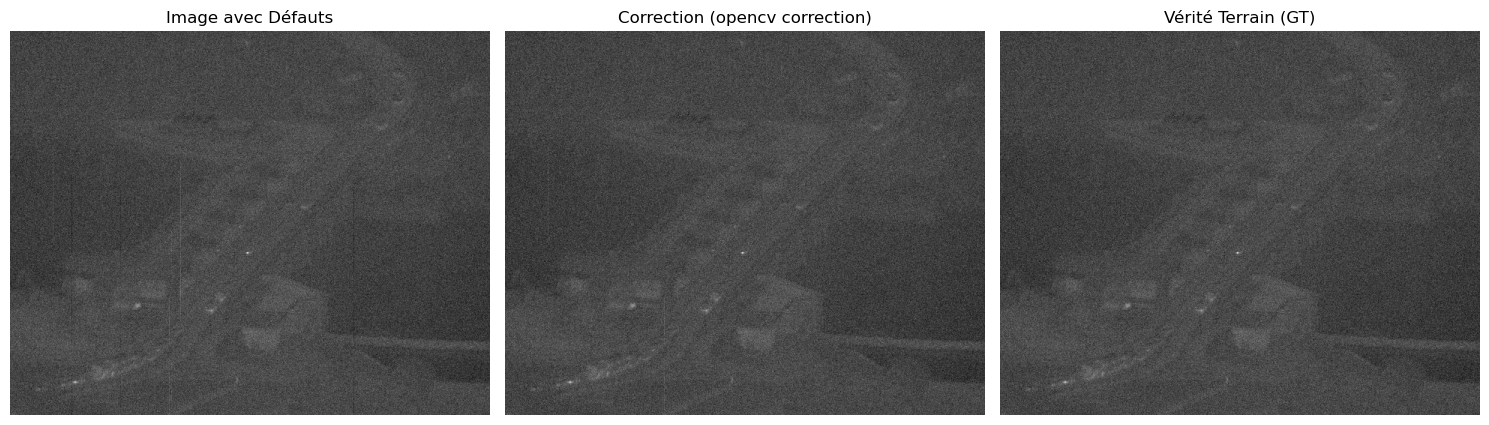

{82: {'start': [192, 329, 456], 'stop': [295, 416, 512], 'type': 'blinking'}, 147: {'start': [203, 364, 457], 'stop': [324, 428, 509], 'type': 'noisy'}, 215: {'start': [266, 442], 'stop': [326, 501], 'type': 'noisy'}, 227: {'start': [176], 'stop': [387], 'type': 'blinking'}, 326: {'start': [48], 'stop': [311], 'type': 'noisy_blinking'}, 445: {'start': [46, 459], 'stop': [393, 512], 'type': 'noisy_blinking'}, 458: {'start': [208, 363, 462], 'stop': [322, 415, 512], 'type': 'noisy'}, 502: {'start': [318, 462], 'stop': [437, 512], 'type': 'blinking'}}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Chemins
img_path_def = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\VGA\sequence_1\low dyn with columns 2\frame_0046.png"
img_path_gt = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\VGA\sequence_1\low dyn\frame_0046.png"
json_path = r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\VGA\sequence_1\low dyn with columns 2\VGA_sequence_1_config_2.json"

img_def = load_image(img_path_def)
img_gt = load_image(img_path_gt)
json_data = load_json(json_path)
defects = get_defect_coordinates(json_data, 497) # Le nombre corespond au chiffre de l'image

img_corrigee = horizontal_interpolation_correction(img_def.astype(np.float32), defects)

# Affichage
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Image avec Défauts")
plt.imshow(normalize_to_8bit(img_def), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Correction (opencv correction)")
plt.imshow(normalize_to_8bit(img_corrigee), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Vérité Terrain (GT)")
plt.imshow(normalize_to_8bit(img_gt), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(defects) # POur regarder a peut près où son les defects

# Itération

In [ ]:
def load_dataset(folder='train', hight_dyn=(True)):
    """
    function that load all the data set paths

    return : 
    dict : with every concept containing image paths
    list : with every image path
    """
    types = ['HD', 'SXGA', 'VGA']
    sequences = ['sequence_1', 'sequence_2', 'sequence_3']
    if hight_dyn == True :
        dynamics = [
            'high_dyn',
            'low dyn',
            'low dyn with columns 1',
            'low dyn with columns 2',
            'low dyn with columns 3'
        ]
    else :
        dynamics = [
            'low dyn',
            'low dyn with columns 1',
            'low dyn with columns 2',
            'low dyn with columns 3'
        ]

    dataset_dict = {}
    all_images_list = []

    for t in types:
        dataset_dict[t] = {}
        for seq in sequences:
            dataset_dict[t][seq] = {}
            for dyn in dynamics:

                # Récupère que les fichiers png du dossier
                path_pattern = f"{folder}/{t}/{seq}/{dyn}/*.png"
                
                paths_in_folder = glob.glob(path_pattern)
                
                dataset_dict[t][seq][dyn] = paths_in_folder
                all_images_list.extend(paths_in_folder)

    return dataset_dict, all_images_list

In [ ]:
print(load_dataset(hight_dyn=False)[0])

{'HD': {'sequence_1': {'low dyn': ['train/HD/sequence_1/low dyn\\frame_0000.png', 'train/HD/sequence_1/low dyn\\frame_0001.png', 'train/HD/sequence_1/low dyn\\frame_0002.png', 'train/HD/sequence_1/low dyn\\frame_0003.png', 'train/HD/sequence_1/low dyn\\frame_0004.png', 'train/HD/sequence_1/low dyn\\frame_0005.png', 'train/HD/sequence_1/low dyn\\frame_0006.png', 'train/HD/sequence_1/low dyn\\frame_0007.png', 'train/HD/sequence_1/low dyn\\frame_0008.png', 'train/HD/sequence_1/low dyn\\frame_0009.png', 'train/HD/sequence_1/low dyn\\frame_0010.png', 'train/HD/sequence_1/low dyn\\frame_0011.png', 'train/HD/sequence_1/low dyn\\frame_0012.png', 'train/HD/sequence_1/low dyn\\frame_0013.png', 'train/HD/sequence_1/low dyn\\frame_0014.png', 'train/HD/sequence_1/low dyn\\frame_0015.png', 'train/HD/sequence_1/low dyn\\frame_0016.png', 'train/HD/sequence_1/low dyn\\frame_0017.png', 'train/HD/sequence_1/low dyn\\frame_0018.png', 'train/HD/sequence_1/low dyn\\frame_0019.png', 'train/HD/sequence_1/low 

In [ ]:
print(load_dataset(hight_dyn=False)[1])

['train/HD/sequence_1/low dyn\\frame_0000.png', 'train/HD/sequence_1/low dyn\\frame_0001.png', 'train/HD/sequence_1/low dyn\\frame_0002.png', 'train/HD/sequence_1/low dyn\\frame_0003.png', 'train/HD/sequence_1/low dyn\\frame_0004.png', 'train/HD/sequence_1/low dyn\\frame_0005.png', 'train/HD/sequence_1/low dyn\\frame_0006.png', 'train/HD/sequence_1/low dyn\\frame_0007.png', 'train/HD/sequence_1/low dyn\\frame_0008.png', 'train/HD/sequence_1/low dyn\\frame_0009.png', 'train/HD/sequence_1/low dyn\\frame_0010.png', 'train/HD/sequence_1/low dyn\\frame_0011.png', 'train/HD/sequence_1/low dyn\\frame_0012.png', 'train/HD/sequence_1/low dyn\\frame_0013.png', 'train/HD/sequence_1/low dyn\\frame_0014.png', 'train/HD/sequence_1/low dyn\\frame_0015.png', 'train/HD/sequence_1/low dyn\\frame_0016.png', 'train/HD/sequence_1/low dyn\\frame_0017.png', 'train/HD/sequence_1/low dyn\\frame_0018.png', 'train/HD/sequence_1/low dyn\\frame_0019.png', 'train/HD/sequence_1/low dyn\\frame_0020.png', 'train/HD/se